## 1. SUSAN Corner Detection 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#### Helper Function: `manual_append(mask_list, element)`

To manually append an element to a Python list **without using the built-in `.append()` method**.

**Parameters:**
1. `mask_list` (`list`): The original list to which we want to add a new element.
2. `element` (`any`): The element to append to the list.

**Returns:**
- `new_list` (`list`): A new list containing all elements of `mask_list` followed by `element`.

**How it works:**
1. Create a new list of zeros with length one greater than the original list.
2. Copy each element from the original list into the new list.
3. Set the last element of the new list to the element to append.
4. Return the new list.


In [20]:
def manual_append(mask_list, element):
    new_list = [0] * (len(mask_list) + 1)
    for i in range(len(mask_list)):
        new_list[i] = mask_list[i]
    new_list[len(mask_list)] = element
    return new_list

#### Helper Function: `manual_min(arr)`

To **find the minimum value in a NumPy array without using Python’s built-in `min()` function**.

**Parameters:**
1. `arr` (`numpy.ndarray`): The input array (can be multi-dimensional).

**Returns:**
- `min_val` (`float`): The smallest value in the array.

**How it works:**
1. Flatten the input array to a 1D array (`flat_arr`) to simplify iteration.
2. Initialize `min_val` as the first element of the flattened array.
3. Loop over the remaining elements:
   - If an element is smaller than `min_val`, update `min_val`.
4. Return the final `min_val`.


In [21]:
def manual_min(arr):
    flat_arr = arr.flatten()
    min_val = flat_arr[0]
    for i in range(1, len(flat_arr)):
        if flat_arr[i] < min_val:
            min_val = flat_arr[i]
    return min_val

#### Helper Function: `manual_max(arr)`

To **find the maximum value in a NumPy array without using Python’s built-in `max()` function**.

**Parameters:**
1. `arr` (`numpy.ndarray`): The input array (can be multi-dimensional).

**Returns:**
- `max_val` (`float`): The largest value in the array.

**How it works:**
1. Flatten the input array to a 1D array (`flat_arr`) to simplify iteration.
2. Initialize `max_val` as the first element of the flattened array.
3. Loop over the remaining elements:
   - If an element is greater than `max_val`, update `max_val`.
4. Return the final `max_val`.

In [22]:
def manual_max(arr):
    flat_arr = arr.flatten()
    max_val = flat_arr[0]
    for i in range(1, len(flat_arr)):
        if flat_arr[i] > max_val:
            max_val = flat_arr[i]
    return max_val

#### Helper Function: `manual_argmax(array)`

To **find the index of the maximum value in an array or list without using predefined functions like `np.argmax()`**.

**Parameters:**
1. `array` (`numpy.ndarray` or `list`): The input 1D array or list to search.

**Returns:**
- `max_idx` (`int`): Index of the maximum value in the input array.

**How it works:**
1. Initialize `max_val` with the first element of the array.
2. Initialize `max_idx` as `0`.
3. Loop through the array starting from the second element:
   - If the current element is larger than `max_val`:
     - Update `max_val` with the current element.
     - Update `max_idx` with the current index.
4. Return `max_idx`, which points to the maximum element.

In [23]:
def manual_argmax (array):
    max_val = array[0]
    max_idx = 0
    
    for i in range(1, len(array)):
        if array[i] > max_val:
            max_val = array[i]
            max_idx = i
    
    return max_idx

### `circular_mask` Function

**What it does:**  
This function creates a list of neighbor pixel positions around a center pixel for the SUSAN corner detector. The center pixel itself is **not included**.

**Why:**  
- SUSAN looks at how similar neighboring pixels are to the center pixel.  
- By leaving out the center, corners (where neighbors are very different) will have small USAN values.

**Input:**  
- `radius` (number): how far out from the center to include neighbors.  
  

**Output:**  
- A list of `(dx, dy)` pairs. Each pair tells you the position of a neighbor relative to the center.  

In [24]:
def circular_mask(radius): # rectangular mask (square neighborhood)
    mask = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dx == 0 and dy == 0:
                # skip the center (nucleus) to follow SUSAN's USAN definition
                continue
            mask = manual_append(mask, (dx, dy))
    return mask


### `susan_histogram` Function

**What it does:**  
This function builds a histogram of SUSAN scores **without using NumPy's `histogram` function**.  
- A histogram counts how many pixels have each USAN score.  
- This is used later to find thresholds for corners and edges.

**Why:**  
- SUSAN scores tell us how “corner-like” or “smooth” a pixel is.  
- By counting how many pixels have each score, we can see the distribution and pick thresholds.

**Input:**  
- `scores` (2D array): the USAN values from the SUSAN detector.  
- `bins` (optional, default=256): maximum number of bins (not strictly used because we align bins to integers).

**Output:**  
- `hist`: 1D array of counts for each integer USAN score.  
- `bin_centers`: the corresponding USAN score values (0, 1, 2, …).

**How it works :**  
1. Find the **minimum** and **maximum** USAN values.  
2. Make sure the minimum is 0 (USAN scores are never negative).  
3. Decide the number of integer bins from 0 to the max value.  
4. Flatten the 2D `scores` array into a 1D list.  
5. Loop over each score:  
   - Ignore NaNs.  
   - Clamp negative or too-large values.  
   - Convert to integer bin index using `floor`.  
   - Increment the count for that bin.  
6. Create `bin_centers` as integers from 0 to max USAN score.  
7. Return the histogram counts and bin centers.


In [25]:
def susan_histogram(scores, bins=256):
    minv = manual_min(scores)
    maxv = manual_max(scores)

    # USAN scores are non-negative; ensure the range starts at 0
    min_int = 0
    max_int = max(1, int(np.ceil(maxv)))

    bins = max_int - min_int + 1

    hist = np.zeros(bins, dtype=np.int32)

    flat_scores = scores.flatten()

    # Assign each SUSAN score to an integer bin via floor (clamp top)
    for value in flat_scores:
        if np.isnan(value):
            continue
        # clamp negative (shouldn't happen) and large values
        v = value
        if v < min_int:
            bin_idx = 0
        else:
            bin_idx = int(np.floor(v))
            if bin_idx >= bins:
                bin_idx = bins - 1
        hist[bin_idx] += 1

    # Bin centers are integer USAN values
    bin_centers = np.arange(min_int, max_int + 1, dtype=np.float32)

    return hist, bin_centers

### `susan` Function

**What it does:**  
This function implements the **SUSAN corner detection algorithm** from scratch.  
It calculates a **USAN score** for every pixel to see if it’s a corner, edge, or flat region.

**Why:**  
- SUSAN finds corners without using gradients.  
- Corners have neighbors with very different brightness → small USAN.  
- Flat regions have similar neighbors → large USAN.  
- Edges are in between.

**Inputs:**  
- `image` (2D array): grayscale input image.  
- `t` (float): brightness threshold. Determines how different a neighbor has to be to count as “different.”  
- `radius` (int, default=3): size of the neighborhood mask around each pixel.

**Output:**  
- `scores` (2D array): USAN size for each pixel.  
  - **Small (~0)** → corners  
  - **Medium** → edges  
  - **Large** → homogeneous regions  

**Step by Step:**  
1. Convert image to float for calculations.  
2. Create a **circular mask** around each pixel using `radius`.  
3. Initialize a `scores` array to store USAN values.  
4. Loop over every pixel (ignoring border pixels):  
   - Take the **center pixel intensity**.  
   - Initialize `usan_size = 0`.  
   - Loop over each neighbor in the mask:  
     - Compute the neighbor’s intensity difference from the center.  
     - Apply **exponential decay** `(c_m)` :  
       - Small differences → `c_m ≈ 1` (similar)  
       - Large differences → `c_m ≈ 0` (different)  
     - Add `c_m` to `usan_size`.  
   - Store `usan_size` in the `scores` array.  
5. Return the 2D `scores` array for the entire image.

-----------------
- The USAN score measures how many **similar neighbors** a pixel has.  
- **Corners** = few similar neighbors → low USAN  
- **Edges** = medium USAN  
- **Flat regions** = many similar neighbors → high USAN


In [26]:
def susan(image, t, radius=3):
    h, w = image.shape
    
    img = image.astype(np.float32)
    
    mask = circular_mask(radius)
    
    scores = np.zeros((h, w), dtype=np.float32)
    
    for y in range(radius, h - radius):
        for x in range(radius, w - radius):
            # nucleus intensity
            center_intensity = img[y, x]
            
            usan_size = 0.0
            
            # Sum brightness similarity across mask
            for b, a in mask:
                ny = y + a
                nx = x + b
                
                neighbor_intensity = img[ny, nx]
                
                intensity_diff = neighbor_intensity - center_intensity
                
                # Exponential decay: large differences → c_m ≈ 0
                c_m = np.exp(-((intensity_diff / t) ** 6))
                
                usan_size += c_m
            
            # Store raw USAN: small value = corner, large value = homogeneous
            scores[y, x] = usan_size
    
    return scores

### 2a Convex Hull Implementation 

### `CalculateHullPoints` Function

**What it does:**  
This function calculates the **upper convex hull** of a 1D histogram.  
- The convex hull is like a “tight rubber band” stretched over the histogram peaks from above.  
- It is used to find **thresholds** by comparing the histogram to the hull.

**Inputs:**  
- `histogram` (1D array): the histogram values (from SUSAN scores).

**Outputs:**  
- `hull_points` (list of tuples): consecutive pairs of indices representing vertices of the upper hull.  
  - Example: `[(2, 5), (5, 10), ...]`  

**Step by Step:**  
1. If the histogram is empty, return an empty list.  
2. Convert the histogram to a list of `(x, y)` points.  
   - `x` = bin index  
   - `y` = histogram value at that index  
3. Initialize an empty `upper` list to store hull points.  
4. Loop through each point in order (left to right):  
   - While there are at least 2 points in `upper`, check the **turn direction** using the **cross product**:  
     - `(x2-x1, y2-y1) × (x3-x1, y3-y1)`  
     - If the cross product ≥ 0 → not a clockwise turn → pop the last point.  
     - Else → keep it.  
   - Add the current point to `upper`.  
5. Convert `upper` points into consecutive **segments** `(start_index, end_index)` for easier threshold calculation.  
6. If the hull has only one point, create a degenerate segment `(idx, idx)`.  
7. Return the list of hull segments.

------------------------- 
- Finds the **upper convex shape** of the histogram.  
- Helps in **detecting thresholds** where the histogram deviates from a smooth convex shape.  
- Core idea: removes “inner valleys” and keeps the **outer envelope** of the histogram.


In [27]:
def CalculateHullPoints(histogram):
    n = len(histogram)
    if n == 0:
        return []

    # Build list of (x, y) points
    points = [(i, float(histogram[i])) for i in range(n)]

    # Compute upper hull using monotone chain (scan left->right)
    upper = []  # will contain points (x, y)
    for p in points:
        while len(upper) >= 2:
            x1, y1 = upper[-2]
            x2, y2 = upper[-1]
            x3, y3 = p
            # Cross product (x2-x1, y2-y1) x (x3-x1, y3-y1)
            cross = (x2 - x1) * (y3 - y1) - (y2 - y1) * (x3 - x1)
            # For upper hull we pop while the turn is non-clockwise (cross >= 0)
            if cross >= 0:
                upper.pop()
            else:
                break
        upper.append(p)

    # Convert consecutive hull vertices into segment pairs (start_index, end_index)
    hull_points = []
    for i in range(len(upper) - 1):
        start_idx = int(upper[i][0])
        end_idx = int(upper[i + 1][0])
        hull_points.append((start_idx, end_idx))

    # If upper contains only a single point, create a degenerate segment
    if len(upper) == 1:
        idx = int(upper[0][0])
        hull_points = [(idx, idx)]

    # Debug print (can be removed later)
    # print("hull points", hull_points)
    return hull_points

### `GetHullValues` Function

**What it does:**  
This function takes the **hull segments** (from `CalculateHullPoints`) and computes the **straight line values** for each bin in the histogram.  
- Essentially, it **connects the hull points with straight lines** to form the “upper envelope curve.”

**Inputs:**  
- `hull_points` (list of tuples): segments of the hull, e.g., `[(2,5), (5,10)]`  
- `histogram` (1D array): the original histogram values  

**Outputs:**  
- `hull_values` (1D array): the y-values of the hull at each histogram index.  

**Step by Step:**  
1. Initialize `hull_values` as zeros, same length as histogram.  
2. Loop through each hull segment `(start, end)`:  
   - If `start == end`, just set `hull_values[start] = histogram[start]`.  
   - Otherwise:  
     1. Take the histogram values at the start (`h_i`) and end (`h_j`) of the segment.  
     2. Compute the slope `m = (h_j - h_i) / (end - start)`.  
     3. Compute the intercept `c = h_i - m*start`.  
     4. Fill in the values along the line: `hull_values[x] = m*x + c` for all x in `[start, end]`.  
3. Return the full array of `hull_values`.  

----------------------------
- Converts the convex hull points into a **continuous line over the histogram**.  
- Later used to **compare the histogram to the hull** and detect thresholds.


In [28]:
def GetHullValues(hull_points, histogram):
    n = len(histogram)
    hull_values = np.zeros(n, dtype=np.float32)
    
    for start, end in hull_points:
        if start == end:
            hull_values[start] = histogram[start]
            continue
        
        h_i = histogram[start]  
        h_j = histogram[end]    
        
        m = (h_j - h_i) / (end - start)
        
        c = h_i - m * start
        
        for x in range(start, end + 1):
            hull_values[x] = m * x + c
    
    return hull_values

### `GetThreshold` Function

**What it does:**  
This function finds the **optimal threshold** from a histogram using the **convex hull method**.  
- The idea: the threshold is the bin where the **difference between the convex hull and the actual histogram** is the largest.  
- This is useful in SUSAN corner detection to separate **corners, edges, and homogeneous regions**.

**Inputs:**  
- `histogram` (1D array): original histogram of USAN scores  
- `hull_values` (1D array): values of the convex hull (from `GetHullValues`)  

**Outputs:**  
- `threshold` (int): index of the histogram that represents the **best separation point**

**Step by Step:**  
1. Compute the **difference** between the hull and the histogram
2. Find the index of the maximum difference:
3. Return this index as the threshold:


In [29]:
def GetThreshold(histogram, hull_values):
    differences = hull_values - histogram
    
    threshold_idx = manual_argmax(differences)
    
    return int(threshold_idx)

### `ApplyThresh` Function

1. **Purpose:**  
   Split a histogram into two parts at a given threshold index.

2. **Inputs:**  
   - `histogram`: the full 1D histogram array  
   - `threshold`: the index at which to split

3. **Process:**  
   - Initialize two arrays of zeros, same size as the histogram:
     ```python
     below_thresh = np.zeros(n, dtype=histogram.dtype)
     above_thresh = np.zeros(n, dtype=histogram.dtype)
     ```
   - Iterate over each histogram bin:
     ```python
     for i in range(n):
         if i <= threshold:
             below_thresh[i] = histogram[i]
         else:
             above_thresh[i] = histogram[i]
     ```
     - If the bin index `i` is **less than or equal** to the threshold, assign it to `below_thresh`.
     - Otherwise, assign it to `above_thresh`.

4. **Output:**  
   - `below_thresh`: histogram values from 0 up to the threshold  
   - `above_thresh`: histogram values above the threshold  

5. **Debugging:**  
   - Prints the two arrays to visualize how the histogram was split:
     ```python
     print("below", below_thresh)
     print("above", above_thresh)
     ```

This function separates the histogram into "lower" and "upper" parts based on the threshold, useful for two-pass convex hull thresholding.


In [30]:
def ApplyThresh(histogram, threshold):
    n = len(histogram)
    
    below_thresh = np.zeros(n, dtype=histogram.dtype)
    above_thresh = np.zeros(n, dtype=histogram.dtype)
    
    for i in range(n):
        if i <= threshold:
            below_thresh[i] = histogram[i]
        else:
            above_thresh[i] = histogram[i]
            
    return below_thresh, above_thresh


#### 2b Two Pass Threshold Implementation

### `two_pass_convex_hull_threshold` Function

1. **Purpose:**  
   Apply convex hull thresholding twice on a histogram to automatically find two thresholds:  
   - **Lower threshold:** separates corners from edges  
   - **Upper threshold:** separates edges from homogeneous regions  

2. **Process Overview:**  
   The algorithm works in **two passes**:

---

#### **FIRST PASS – Upper Threshold**
- **Step 1:** Compute the **upper convex hull** of the histogram using `CalculateHullPoints`.
- **Step 2:** Get the hull values along the histogram using `GetHullValues`.
- **Step 3:** Find the **upper threshold** index as the point where the difference `Hull - Histogram` is maximum (`GetThreshold`).
- **Step 4:** Split histogram at this threshold using `ApplyThresh` into:
  - `below_upper`: bins ≤ upper threshold  
  - `above_upper`: bins > upper threshold  

This identifies the **boundary between edges and homogeneous regions**.

---

#### **SECOND PASS – Lower Threshold**
- **Step 1:** Trim the `below_upper` histogram to remove trailing zeros. This avoids bias from empty bins.
- **Step 2:** Check for a valid sub-histogram:
  - If all bins are zero, fallback to `upper_threshold - 1`
  - If sub-histogram is degenerate (single bin or all zeros), fallback similarly
- **Step 3:** Compute convex hull on the trimmed sub-histogram
- **Step 4:** Find **lower threshold** relative to the trimmed sub-histogram using `GetThreshold`
- **Step 5:** Map this relative index back to the **global histogram** by adding the start index of the trimmed region  

This identifies the **boundary between corners and edges**.

---

#### **Post-processing**
- Ensure `threshold1 < threshold2` (lower < upper)
- Assign:
  - `threshold1` → lower threshold (corners vs edges)
  - `threshold2` → upper threshold (edges vs homogeneous)
- Output **regions** based on thresholds:
  - `0 … threshold1` → corners  
  - `threshold1+1 … threshold2` → edges  
  - `threshold2+1 … end` → homogeneous

---

- **First pass:** finds the upper threshold separating edges from homogeneous areas.  
- **Second pass:** finds the lower threshold separating corners from edges.  
- Handles edge cases (empty bins, degenerate sub-histograms) to ensure robustness.  
- Returns `(threshold1, threshold2)` as **indices in the histogram**.


In [31]:
def two_pass_convex_hull_threshold(histogram):
    hull_points_1 = CalculateHullPoints(histogram)
    hull_values_1 = GetHullValues(hull_points_1, histogram)
    upper_threshold = GetThreshold(histogram, hull_values_1)

    below_upper, above_upper = ApplyThresh(histogram, upper_threshold)

    nonzero_idx = np.where(below_upper > 0)[0]
    if len(nonzero_idx) == 0:
        lower_threshold = max(0, upper_threshold - 1)
    else:
        start = int(nonzero_idx[0])
        end = int(nonzero_idx[-1])
        sub_hist = below_upper[start:end+1]

        if len(sub_hist) <= 1 or manual_max(sub_hist) == 0:
            lower_threshold = max(0, upper_threshold - 1)
        else:
            hull_points_2 = CalculateHullPoints(sub_hist)
            hull_values_2 = GetHullValues(hull_points_2, sub_hist)
            lower_rel = GetThreshold(sub_hist, hull_values_2)
            lower_threshold = int(lower_rel) + start

    threshold1 = int(lower_threshold)
    threshold2 = int(upper_threshold)

    if threshold1 >= threshold2:
        threshold1 = max(0, threshold2 - 1)

    return threshold1, threshold2


### 3. Draw Image


### `DrawImages` Function

1. **Purpose:**  
   Split a SUSAN corner-detection image into **three regions** based on two thresholds:  
   - **Lower region:** corners (small USAN values)  
   - **Middle region:** edges (medium USAN values)  
   - **Higher region:** homogeneous areas (large USAN values)  

2. **Inputs:**  
   - `threshold1` → lower threshold (corners vs edges)  
   - `threshold2` → upper threshold (edges vs homogeneous)  
   - `susan_image` → 2D array with SUSAN scores for each pixel  

3. **Outputs:**  
   - **Region images (float):**
     - `lower_region` → only pixels ≤ `threshold1` retain values, others are 0  
     - `mid_region` → only pixels between `threshold1` and `threshold2`  
     - `higher_region` → only pixels > `threshold2`  
   - **Boolean masks (True where pixel belongs to region):**
     - `lower_mask`, `mid_mask`, `higher_mask`  

4. **Step-by-step :**  
   For each pixel `(i, j)` in the SUSAN image:  
   - If `pixel_value <= threshold1` → assign to **lower region** and mark `lower_mask[i, j] = True`  
   - If `threshold1 < pixel_value <= threshold2` → assign to **mid region** and mark `mid_mask[i, j] = True`  
   - If `pixel_value > threshold2` → assign to **higher region** and mark `higher_mask[i, j] = True`  

5. **Purpose of Masks:**  
   - Boolean masks allow easy visualization or further processing (highlighting corners or edges).  

-----------
 
   This function effectively segments the SUSAN score image into **corners, edges, and homogeneous areas** while providing both **visualizable images** and **binary masks** for each region.


In [32]:
def DrawImages(threshold1, threshold2, susan_image):
    lower_region = np.zeros_like(susan_image)
    mid_region = np.zeros_like(susan_image)
    higher_region = np.zeros_like(susan_image)

    lower_mask = np.zeros_like(susan_image, dtype=bool)
    mid_mask = np.zeros_like(susan_image, dtype=bool)
    higher_mask = np.zeros_like(susan_image, dtype=bool)

    for i in range(susan_image.shape[0]):
        for j in range(susan_image.shape[1]):
            pixel_value = susan_image[i, j]

            if pixel_value <= threshold1:
                lower_region[i, j] = pixel_value
                lower_mask[i, j] = True
            elif threshold1 < pixel_value <= threshold2:
                mid_region[i, j] = pixel_value
                mid_mask[i, j] = True
            else:
                higher_region[i, j] = pixel_value
                higher_mask[i, j] = True

    return lower_region, mid_region, higher_region, lower_mask, mid_mask, higher_mask

### Corner & Edge Post-processing Functions

This group of functions is used to **refine and visualize corners and edges** after SUSAN corner detection.

- `extract_corner_points` → finds precise corner locations  
- `thin_edges` → creates clear edge outlines  
- `dilate_points` → enlarges points for display  


In [33]:
def extract_corner_points(susan_response, corner_mask, neighborhood=1, margin=0.0):
    h, w = susan_response.shape
    points_mask = np.zeros_like(corner_mask, dtype=bool)

    ys, xs = np.where(corner_mask)
    for y, x in zip(ys, xs):
        y0 = max(0, y - neighborhood)
        y1 = min(h - 1, y + neighborhood)
        x0 = max(0, x - neighborhood)
        x1 = min(w - 1, x + neighborhood)

        local = susan_response[y0:y1+1, x0:x1+1]
        center_val = susan_response[y, x]
        cy = y - y0
        cx = x - x0
        local_no_center = local.copy()
        local_no_center[cy, cx] = np.inf

        if center_val + margin < np.min(local_no_center):
            points_mask[y, x] = True

    return points_mask


def thin_edges(mask, iterations=1):
    m = mask.astype(bool)
    if m.size == 0:
        return m

    h, w = m.shape
    out = m.copy()

    for _ in range(max(0, int(iterations))):
        padded = np.pad(out, pad_width=1, mode='constant', constant_values=False)
        eroded = np.zeros_like(out, dtype=bool)
        for y in range(h):
            for x in range(w):
                block = padded[y:y+3, x:x+3]
                if block.all():
                    eroded[y, x] = True
        out = eroded

    outline = m & (~out)
    return outline


def dilate_points(mask, radius=1):
    if mask is None:
        return None
    m = mask.astype(bool)
    if m.size == 0:
        return m

    h, w = m.shape
    dil = np.zeros_like(m, dtype=bool)
    ys, xs = np.where(m)
    r = max(0, int(radius))
    for y, x in zip(ys, xs):
        y0 = max(0, y - r)
        y1 = min(h, y + r + 1)
        x0 = max(0, x - r)
        x1 = min(w, x + r + 1)
        dil[y0:y1, x0:x1] = True
    return dil


### `plot_comprehensive_results` Function:

This function is designed to **visualize the entire SUSAN corner detection pipeline** in a single figure, showing the original image, corner and edge overlays, USAN scores, histograms, and segmented regions.

---

#### **Inputs**
- `original`: Original grayscale image (2D array)
- `susan_response`: USAN response (2D float array)
- `histogram`: 1D array of USAN values
- `bin_centers`: x-axis values for histogram (USAN scores)
- `t1`, `t2`: lower and upper thresholds (from convex hull thresholding)
- `corners`, `edges`, `homogeneous`: float-valued images for each region
- `corner_points`: boolean mask of detected corner points
- `edge_outline`: optional boolean mask of thin edges
- `t_parameter`: the `t` value used in SUSAN for display
- `show_points`: whether to overlay scatter markers on original and SUSAN response
- `corner_dilate`: radius to dilate single-pixel corner points for better visibility


#### **Workflow**
1. **Prepare RGB overlay**
   - Convert grayscale original to RGB.
   - Overlay **edges** in white.
   - Optionally overlay **corner points** as red dots.

2. **Plot SUSAN response**
   - Display USAN response as a grayscale image.
   - Optionally overlay **corner points** in yellow.

3. **Plot histogram**
   - Plot USAN histogram vs `bin_centers`.
   - Overlay **threshold lines** (`t1`, `t2`).

4. **Display segmented regions**
   - **CORNERS**: show dilated corner points as white spots.
   - **EDGES**: show thin edge outlines or edge mask.
   - **HOMOGENEOUS**: show pixels above the upper threshold.

5. **Layout**
   - 3 rows × 4 columns figure (some subplots may be empty).
   - Titles, colorbars, and labels for clarity.
   - Tight layout ensures all plots fit nicely.


#### **Outputs**
- Returns the **matplotlib Figure object** 


#### **Key Notes**
- `dilate_points` is used to enlarge corner points for better visualization.
- `edge_outline` can be used for thin edges; otherwise, the raw edge mask is displayed.

In [34]:
def plot_comprehensive_results(original, susan_response, histogram, 
                               bin_centers, t1, t2, corners, edges, homogeneous, corner_points, edge_outline=None, t_parameter=0, show_points=False, corner_dilate=1):

    def _ensure_rgb(img):
        if img.ndim == 2:
            return np.dstack([img, img, img]).astype(np.uint8)
        return img.copy()

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f't={t_parameter}: SUSAN Corner Detection Results', fontsize=16, fontweight='bold')

    combined = _ensure_rgb(original)

    if edge_outline is not None:
        epts = edge_outline.astype(bool)
        combined = combined.copy()
        combined[epts, 0] = 255
        combined[epts, 1] = 255
        combined[epts, 2] = 255

    plt.subplot(3, 4, 1)
    ax0 = plt.gca()
    im0 = ax0.imshow(combined, origin='upper')
    ax0.set_title('1. Original Image + Corners + Edges', fontsize=14, fontweight='bold')
    ax0.axis('off')

    if show_points and corner_points is not None:
        ys, xs = np.where(corner_points.astype(bool))
        if xs.size > 0:
            ax0.scatter(xs, ys, s=50, c='red', marker='o', edgecolors='black', linewidths=0.6, zorder=10)

    plt.subplot(3, 4, 2)
    ax1 = plt.gca()
    im1 = ax1.imshow(susan_response, cmap='gray', origin='upper')
    ax1.set_title('2. SUSAN Response', fontsize=14, fontweight='bold')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    ax1.axis('off')

    if show_points and corner_points is not None:
        ys, xs = np.where(corner_points.astype(bool))
        if xs.size > 0:
            ax1.scatter(xs, ys, s=30, c='yellow', marker='o', edgecolors='black', linewidths=0.4, zorder=10)

    plt.subplot(3, 4, 3)
    if len(bin_centers) == len(histogram):
        x = bin_centers
    else:
        x = np.arange(len(histogram))

    plt.plot(x, histogram, 'b-', linewidth=2)
    
    plt.axvline(t1, color='r', linestyle='--', linewidth=2.5, label=f'T1={t1:.1f}')
    plt.axvline(t2, color='g', linestyle='--', linewidth=2.5, label=f'T2={t2:.1f}')
    
    plt.title('3. Histogram + Thresholds (USAN domain)', fontsize=14, fontweight='bold')
    plt.xlabel('USAN score', fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 4, 5)
    ax2 = plt.gca()
    if corner_points is not None:
        dilated = dilate_points(corner_points.astype(bool), radius=corner_dilate)
        corner_img = np.zeros_like(corners, dtype=np.uint8)
        corner_img[dilated] = 255
        im2 = ax2.imshow(corner_img, cmap='gray', origin='upper', interpolation='nearest')
    else:
        im2 = ax2.imshow(corners, cmap='gray', origin='upper')
    ax2.set_title(f'5. CORNERS\n(x ≤ {t1:.1f})', fontsize=14, fontweight='bold')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    ax2.axis('off')

    plt.subplot(3, 4, 6)
    ax3 = plt.gca()
    if edge_outline is not None:
        im3 = ax3.imshow(edge_outline, cmap='gray', origin='upper')
    else:
        im3 = ax3.imshow(edges, cmap='gray', origin='upper')
    ax3.set_title(f'6. EDGES\n({t1:.1f} < x ≤ {t2:.1f})', fontsize=14, fontweight='bold')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    ax3.axis('off')

    plt.subplot(3, 4, 7)
    ax4 = plt.gca()
    im4 = ax4.imshow(homogeneous, cmap='gray', origin='upper')
    ax4.set_title(f'7. HOMOGENEOUS\n(x > {t2:.1f})', fontsize=14, fontweight='bold')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    ax4.axis('off')

    plt.tight_layout()
    return fig


### Complete SUSAN Pipeline Function: `run_complete_pipeline`

This function executes the **entire SUSAN corner detection workflow** from loading the image to visualizing results and returning detailed outputs.

#### **Inputs**
- `image_path`: Path to input image.
- `t_parameter`: Brightness threshold for SUSAN similarity function (default: 27).
- `radius`: Radius for circular neighborhood mask (default: 3).
- `nms_neighborhood`: Neighborhood radius for NMS (default: 2).
- `nms_margin`: Margin for strict local minima in NMS (default: 0.5).
- `show_points`: Boolean; whether to overlay corner scatter points in visualizations.


#### **Workflow Steps**

1. **Load and preprocess image**
   - Convert to grayscale if necessary.
   - Print shape and confirmation.

2. **Compute SUSAN response**
   - Run `susan()` on the grayscale image.
   - The **USAN response** is stored in `susan_response`.
   - Print min/max USAN scores.

3. **Extract interior scores**
   - Avoid border artifacts by using only pixels **radius away from edges**.
   - Print interior region size and USAN range.

4. **Compute histogram**
   - Use `susan_histogram()` on interior scores.
   - Returns `histogram` and `bin_centers`.

5. **Apply two-pass convex hull thresholding**
   - Compute **upper and lower thresholds** (`threshold1_idx`, `threshold2_idx`) from histogram.
   - Map **bin indices to actual USAN scores** using `bin_centers`.

6. **Segment image into regions**
   - `DrawImages()` divides image into:
     - **Corners** (lower_region)
     - **Edges** (mid_region)
     - **Homogeneous** (higher_region)
   - Also returns boolean masks for each region.

7. **Localize corner points**
   - `extract_corner_points()` performs **non-maximum suppression** to find precise corners.
   - Optionally dilate points for visibility using `dilate_points()`.

8. **Thin edges**
   - `thin_edges()` creates 1-pixel-wide outlines for edge regions.

9. **Compute statistics**
   - Count pixels in corners, edges, homogeneous regions.
   - Print region statistics with percentages.

10. **Visualization**
    - `plot_comprehensive_results()` displays:
      - Original image with corners and edges overlay
      - SUSAN response
      - Histogram with thresholds
      - Segmented regions (corners, edges, homogeneous)
      - Optional corner point overlays for debugging

11. **Return dictionary**
    - Contains all intermediate results, masks, thresholds, corner points, and figure object.


#### **Outputs**
- `susan_response`: USAN scores
- `histogram` & `bin_centers`: Histogram data
- `threshold1`, `threshold2`: Mapped SUSAN thresholds
- `threshold1_idx`, `threshold2_idx`: Histogram bin indices
- `corners`, `edges`, `homogeneous`: float-valued region images
- `corner_mask`, `edge_mask`, `homog_mask`: boolean masks
- `corner_points`, `corner_points_dilated`: localized corner points
- `edge_outline`: thin edge mask
- `figure`: Matplotlib figure for visualization
- `nms_neighborhood`, `nms_margin`: NMS parameters used



In [35]:
def run_complete_pipeline(image_path, t_parameter=27, radius=3, nms_neighborhood=2, nms_margin=0.5, show_points=False):
    print(f"Loading image: {image_path}")
    image = Image.open(image_path)
    image_array = np.array(image)

    if len(image_array.shape) == 3:
        gray_image = np.mean(image_array, axis=2).astype(np.uint8)
    else:
        gray_image = image_array.astype(np.uint8)
    print(f"✓ Image loaded: {gray_image.shape}")

    # Step 1: Run SUSAN to get scores
    susan_response = susan(gray_image, t=t_parameter, radius=radius)
    print("✓ SUSAN response computed.")
    print(f"  SUSAN score range: [{manual_min(susan_response):.2f}, {manual_max(susan_response):.2f}]")

    # Step 2: Extract INTERIOR region for histogram (avoid border artifacts)
    h, w = susan_response.shape
    interior_scores = susan_response[radius:h-radius, radius:w-radius]
    print(f"  Interior region size: {interior_scores.shape}")
    print(f"  Interior score range: [{manual_min(interior_scores):.2f}, {manual_max(interior_scores):.2f}]")

    # Step 3: Create histogram from INTERIOR SUSAN scores only
    histogram, bin_centers = susan_histogram(interior_scores, bins=256)
    print("✓ Histogram created from interior SUSAN scores.")

    # Step 4: Apply convex hull thresholding (returns bin indices)
    threshold1_idx, threshold2_idx = two_pass_convex_hull_threshold(histogram)
    print("✓ Convex hull thresholds determined (histogram bin indices).")

    # Step 5: Map bin indices to actual SUSAN score values using bin centers
    threshold1 = float(bin_centers[threshold1_idx]) if len(bin_centers) > 0 else 0.0
    threshold2 = float(bin_centers[threshold2_idx]) if len(bin_centers) > 0 else 0.0
    print(f"  Mapped to SUSAN scores: T1={threshold1:.2f}, T2={threshold2:.2f}")

    # Step 6: Segment regions using actual SUSAN score thresholds
    lower_region, mid_region, higher_region, lower_mask, mid_mask, higher_mask = DrawImages(
        threshold1, threshold2, susan_response
    )
    print("✓ Regions segmented based on thresholds.")

    # Thin corners to point locations using NMS (use configurable neighborhood + margin)
    corner_points = extract_corner_points(susan_response, lower_mask, neighborhood=nms_neighborhood, margin=nms_margin)

    # Create a dilated corner mask (make points more visible) - choose radius 2 by default
    corner_points_dilated = dilate_points(corner_points, radius=2)

    # Create thin outlines for edge regions (1-pixel wide)
    edge_outline = thin_edges(mid_mask, iterations=1)

    # For compatibility with earlier variable names used in plotting/returns
    corners = lower_region
    edges = mid_region
    homogeneous = higher_region

    # Statistics (use masks for accurate counts)
    total_pixels = gray_image.shape[0] * gray_image.shape[1]
    corners_count = int(np.sum(lower_mask))
    edges_count = int(np.sum(mid_mask))
    homog_count = int(np.sum(higher_mask))

    print(f"Region Statistics:")
    print(f"  Corners:      {corners_count:8d} pixels ({corners_count/total_pixels*100:6.2f}%)")
    print(f"  Edges:        {edges_count:8d} pixels ({edges_count/total_pixels*100:6.2f}%)")
    print(f"  Homogeneous:  {homog_count:8d} pixels ({homog_count/total_pixels*100:6.2f}%)")
    print(f"  Total:        {total_pixels:8d} pixels")

    # Visualization (pass corner_points and edge_outline to show overlay)
    # Pass corner_dilate=2 so CORNERS subplot displays a thicker/darker point for visibility
    fig = plot_comprehensive_results(
        gray_image, susan_response, histogram,
        bin_centers, threshold1, threshold2,  # pass bin centers and USAN thresholds
        corners, edges, homogeneous, corner_points, edge_outline, t_parameter, show_points=show_points, corner_dilate=2,
    )

    print("Processing complete!")

    return {
        'susan_response': susan_response,
        'histogram': histogram,
        'bin_centers': bin_centers,
        'threshold1': threshold1,
        'threshold2': threshold2,
        'threshold1_idx': threshold1_idx,
        'threshold2_idx': threshold2_idx,
        'corners': corners,
        'edges': edges,
        'homogeneous': homogeneous,
        'corner_mask': lower_mask,
        'edge_mask': mid_mask,
        'homog_mask': higher_mask,
        'corner_points': corner_points,
        'corner_points_dilated': corner_points_dilated,
        'edge_outline': edge_outline,
        'figure': fig,
        'nms_neighborhood': nms_neighborhood,
        'nms_margin': nms_margin,
    }


### Running the SUSAN Pipeline on test images with Different t-values

#### **Purpose**
- Execute the full SUSAN detection pipeline on the image 
- Test the effect of **different brightness thresholds `t`** on corner/edge detection.


Loading image: Test Image.png
✓ Image loaded: (512, 768)
✓ SUSAN response computed.
  SUSAN score range: [0.00, 8.00]
  Interior region size: (510, 766)
  Interior score range: [0.00, 8.00]
✓ Histogram created from interior SUSAN scores.
✓ Convex hull thresholds determined (histogram bin indices).
  Mapped to SUSAN scores: T1=3.00, T2=6.00
✓ Regions segmented based on thresholds.
Region Statistics:
  Corners:         81235 pixels ( 20.66%)
  Edges:          126277 pixels ( 32.11%)
  Homogeneous:    185704 pixels ( 47.23%)
  Total:          393216 pixels
Processing complete!


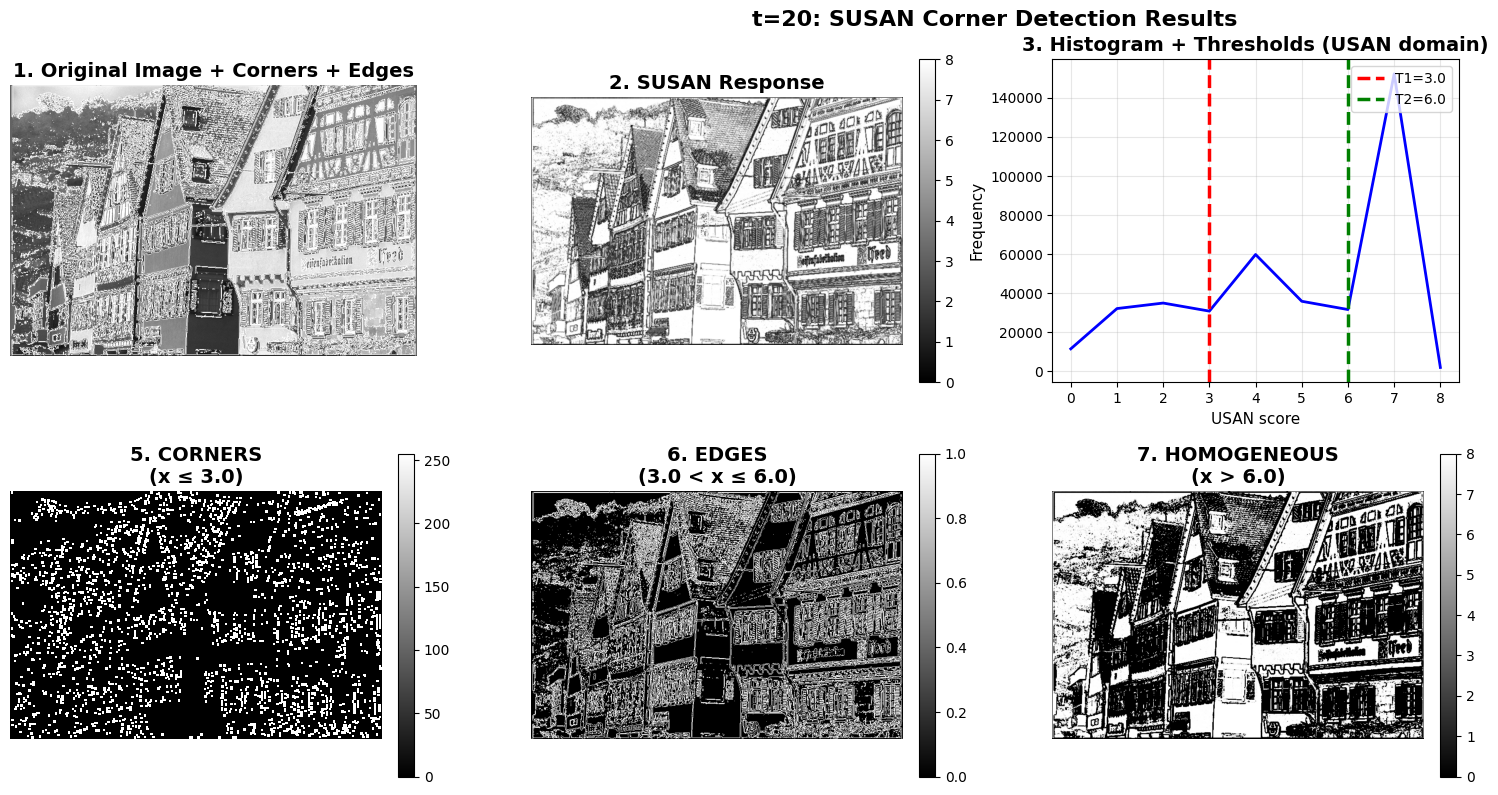

In [36]:
   
image_path = 'Test Image.png'
# results = run_complete_pipeline(image_path, t_parameter=27, radius=3)
# plt.show()

t_values = [20]

for idx, t in enumerate(t_values):
   # print(f"\nTesting with t={t}...")
    result = run_complete_pipeline(image_path, t_parameter=t, radius=1)
